In [4]:
# ==========================================================
# Celda 01 — Importación de paquetes
# ==========================================================
import sys
import os
from datetime import datetime

import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

from scipy.linalg import sqrtm
from scipy.linalg import inv

sys.path.insert(0, '../')
from codes.Quantum import *
from codes.CSPSA import *

from joblib import Parallel, delayed

In [55]:
# ==========================================================
# Celda 02 — Definición de funciones auxiliares
# ==========================================================

def complex2unitary( Z ):
    if Z.ndim == 3:
        for k, z in enumerate(Z):
            Z[k] = z @ inv( sqrtm( z.T.conj()@z ) )
    else:
        Z = Z @ inv( sqrtm( Z.T.conj()@Z ) )
    return Z 

def random_unitary( dim, num=1 ):
    Z = np.random.randn( num, dim, dim ) \
        + 1j*np.random.randn( num, dim, dim )
    return complex2unitary( Z ).squeeze()

def postprocessing(U):
    return complex2unitary( U )

def trineq(Us, Psi ):

    Us = np.array(Us)
    Us = complex2unitary( Us )

    probs = np.abs( LocalProduct( Psi, Us ).reshape(6*[2]) )**2

    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )

    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1] * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality


def _una_repeticion(a, gains, max_iter):
    """
    Ejecuta una única repetición de CSPSA para un valor de alpha dado.
    Diseñada para ejecutarse en paralelo (un núcleo por repetición).
    """
    psi = np.sqrt(a)*np.array([[0, 1, 0, 0]]) + np.sqrt(1-a)*np.array([[0, 0, 1, 0]])
    Psi = triple_kron( psi, psi, psi )
    Psi = Psi.reshape(6*[2]).transpose([5,0,2,1,4,3]).flatten()

    Us_in = np.array([ np.kron(random_unitary(2), random_unitary(2)) for _ in range(3) ])
    cspsa = CSPSA(gains=gains, minimize=False)

    results = cspsa.minimize(trineq, Us_in,
                                max_iter,
                                args = (Psi),
                                postprocessing=postprocessing )
    return results.fun


def ejecutar_simulacion(alphas, max_rep, max_iter, gains, sim_id, carpeta_sim,
                         fecha=None, n_jobs=-1):
    """
    Ejecuta CSPSA para cada valor de alpha en `alphas`, paralelizando las
    `max_rep` repeticiones entre los núcleos disponibles (n_jobs=-1 usa
    todos los núcleos del equipo). Guarda un archivo .npz por cada alpha
    dentro de la carpeta `carpeta_sim`.
    Nombre de archivo: {sim_id}_alpha{alpha:.2f}_{fecha}.npz

    Cada archivo contiene:
        Out    -> arreglo crudo (max_rep, max_iter) con todas las realizaciones
        mean   -> promedio por iteración
        median -> mediana por iteración
        q1     -> cuartil 25 por iteración
        q3     -> cuartil 75 por iteración
        alpha, gains, max_iter, max_rep, sim_id, fecha -> metadatos
    """
    if fecha is None:
        fecha = datetime.now().strftime("%Y%m%d")

    os.makedirs(carpeta_sim, exist_ok=True)

    for a in alphas:
        print(f"[{sim_id}] alpha = {a:.2f}  (paralelizando {max_rep} repeticiones, n_jobs={n_jobs})")

        resultados = Parallel(n_jobs=n_jobs)(
            delayed(_una_repeticion)(a, gains, max_iter) for _ in range(max_rep)
        )
        Out = np.array(resultados)

        nombre = f"{sim_id}_alpha{a:.2f}_{fecha}.npz"
        ruta = os.path.join(carpeta_sim, nombre)

        np.savez(ruta,
                 Out=Out,
                 mean=Out.mean(axis=0),
                 median=np.median(Out, axis=0),
                 q1=np.percentile(Out, 25, axis=0),
                 q3=np.percentile(Out, 75, axis=0),
                 alpha=a, gains=gains, max_iter=max_iter,
                 max_rep=max_rep, sim_id=sim_id, fecha=fecha)

        print(f"  Guardado: {ruta}")


def graficar_simulacion(alphas, sim_id, carpeta_sim, fecha):
    plt.figure()
    colors = plt.cm.jet(np.linspace(0, 1, len(alphas)))

    for a, color in zip(alphas, colors):
        nombre = f"{sim_id}_alpha{a:.2f}_{fecha}.npz"
        ruta = os.path.join(carpeta_sim, nombre)
        Data = np.load(ruta)

        median = Data['median']
        q1 = Data['q1']
        q3 = Data['q3']
        it = np.arange(len(median))

        label = rf'$\alpha = {a:.2f}$'
        plt.plot(it, median, color=color, label=label)
        plt.fill_between(it, q1, q3, color=color, alpha=0.2)

    plt.xlabel(r"Iterations")
    plt.ylabel(r"Inequality value")
    plt.legend()
    plt.grid()
    plt.savefig(os.path.join(carpeta_sim, f"{sim_id}_{fecha}.pdf"))
    plt.show()

In [56]:
# ==========================================================
# Celda 03 — Mediciones óptimas y validación del funcional trineq
# ==========================================================
M = np.zeros( (2,2,2,2) )

M[0,1,:,:] = np.array([  [1, 0], [0, 1]  ]) #Z
M[0,0,:,:] = np.array([  [1, 1], [1, -1]  ])/np.sqrt(2) #X

M[1,0,0,:] = np.array([1-np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) )  #X+Z
M[1,0,1,:] = np.array([1+np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )

M[1,1,0,:] = np.array([-1-np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )
M[1,1,1,:] = np.array([-1+np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) ) #

Comp_basis = np.eye(2) 

vec_alice = np.zeros( (2,2,4) )
for l in range(2):
    for k in range(2):
        vec_alice[l,k,:]  = np.kron( Comp_basis[l], M[0,l,k,:] )
vec_alice = vec_alice.reshape(4,4)

vec_bob = np.zeros( (2,2,4) )
for m in range(2):
    for kk in range(2):
        vec_bob[m,kk,:] = np.kron( Comp_basis[m], M[1,m,kk,:] )
vec_bob = vec_bob.reshape(4,4)

Comp_basis = np.array([ 0,1,1,0 ]).reshape(2,2)
vec_charlie = np.zeros( (2,2,4) )
for i in range(2):
    for j in range(2):
        vec_charlie[i,j,:] = np.kron( Comp_basis[i], Comp_basis[j] )
vec_charlie = vec_charlie.reshape(4,4)

Psi_ab = np.array([ 0, 1, -1, 0 ])/np.sqrt(2)
Psi = triple_kron( Psi_ab, Psi_ab, Psi_ab )
Psi = Psi.reshape(6*[2]).transpose([5,0,2,1,4,3]).flatten() 
Rho = np.outer( Psi, Psi.conj() )

trineq( np.array([vec_alice, vec_bob, vec_charlie]), Psi ), (np.sqrt(2)-1)/16 


(np.float64(0.02588834764831842), np.float64(0.025888347648318447))

In [57]:
# ==========================================================
# Celda 04 — Documentación: convención de índices por detector
# ==========================================================
# alpha=0,1 beta=2,3 gamma=4,5 
# alice  5,0 ( alpha, gamma ) 
# bob    2,1 ( beta, alpha )
# charli 4,3 ( gamma, beta )


In [58]:
# ==========================================================
# Celda 05 — Verificación de la forma del estado Psi
# ==========================================================
Psi = triple_kron( Psi_ab, Psi_ab, Psi_ab )
Psi.shape ## 64 = 2**6 


(64,)

In [59]:
# ==========================================================
# Celda 06 — Documentación: convención de coeficientes de Psi
# ==========================================================
## |Psi> = sum_{ijklmn} Psi_{ijklmn} |i>|j>|k>|l>|m>|n>
#                                     2  2  2  2  2  2 


In [60]:
# ==========================================================
# Celda 07 — Ejemplo de acceso a componentes de Psi
# ==========================================================
Psi.reshape([2,2,2,2,2,2])[0,1,1]
# i=0, j=1, k=1 ---> Psi_{011lmn}


array([[[-0.        , -0.35355339],
        [ 0.35355339, -0.        ]],

       [[ 0.        ,  0.        ],
        [-0.        ,  0.        ]]])

# Simulación 01

**Carpeta de datos:** `Simulacion_01`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| $\alpha$ | $\{0.0,\ 0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5\}$ |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** barrido en $\alpha$ desde el estado producto ($\alpha=0.0$)
hasta entrelazamiento parcial-máximo ($\alpha=0.5$), aplicado simétricamente
a las tres fuentes de la red triangular. Se guarda, por cada $\alpha$, el
arreglo crudo de las 100 realizaciones junto con promedio, mediana, Q1 y Q3
por iteración.

**Archivos generados:** `Simulacion_01/Sim01_alpha{valor}_{fecha}.npz`


In [6]:
# ==========================================================
# Simulación 01 — Ejecución
# ==========================================================
alphas_sim01 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
max_rep_sim01 = 100
max_iter_sim01 = 1000
gains_sim01 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim01 = "Simulacion_01"
fecha_sim01 = datetime.now().strftime("%Y%m%d")

#ejecutar_simulacion(alphas_sim01, max_rep_sim01, max_iter_sim01,
#                     gains_sim01, "Sim01", carpeta_sim01, fecha_sim01)


In [7]:
import glob

def cargar_ultimo_npz(carpeta, sim_id, alpha):
    patron = os.path.join(carpeta, f"{sim_id}_alpha{alpha:.2f}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para alpha={alpha:.2f} en {carpeta}"
    if len(archivos) > 1:
        print(f"  [aviso] alpha={alpha:.2f} tiene {len(archivos)} archivos, usando el más reciente: {archivos[-1]}")
    return np.load(archivos[-1])

valor_fritz = (np.sqrt(2) - 1) / 16
carpeta_sim01 = "Simulacion_01"
alphas_sim01 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

  [aviso] alpha=0.50 tiene 2 archivos, usando el más reciente: Simulacion_01\Sim01_alpha0.50_20260804.npz


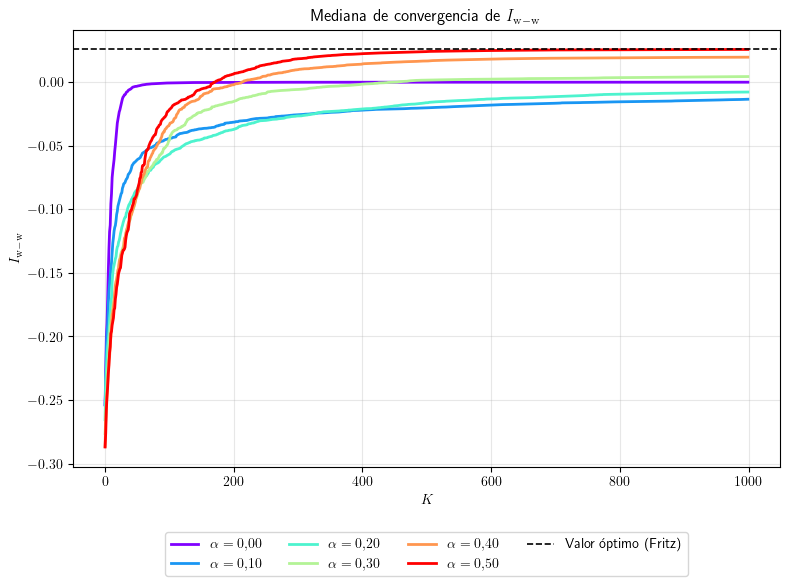

In [9]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(alphas_sim01)))

plt.figure(figsize=(8,6))

for a, color in zip(alphas_sim01, colors):
    Data = cargar_ultimo_npz(carpeta_sim01, "Sim01", a)
    median = Data['median']
    it = np.arange(len(median))

    alpha_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, median, color=color, label=rf"$\alpha = {alpha_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Mediana de convergencia de $I_{\rm w-w}$")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Simulacion_01/Sim01_med.pdf")
plt.savefig("Simulacion_01/Sim01_med.png", dpi=600)
plt.show()

In [ ]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(alphas_sim01)))

plt.figure(figsize=(8,6))

for a, color in zip(alphas_sim01, colors):
    Data = cargar_ultimo_npz(carpeta_sim01, "Sim01", a)
    mean = Data['mean']
    it = np.arange(len(mean))

    alpha_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, mean, color=color, label=rf"$\alpha = {alpha_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Media de $I_{\rm w-w}$ para estados en descomposición de Schmidt")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

NameError: name 'plt' is not defined

  [aviso] alpha=0.50 tiene 2 archivos, usando el más reciente: Simulacion_01\Sim01_alpha0.50_20260804.npz


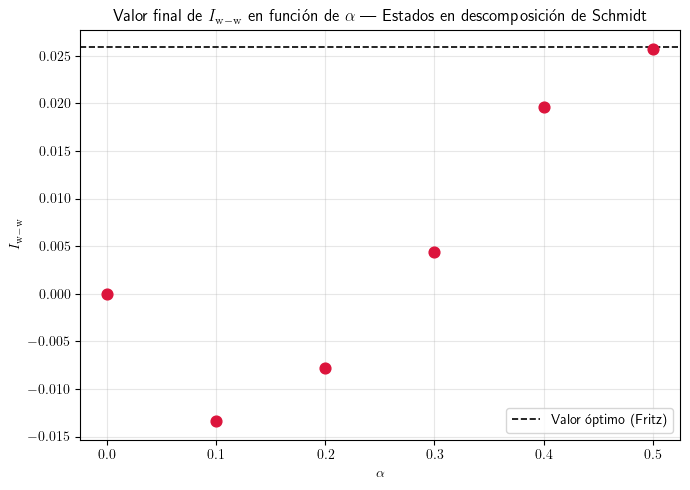

In [80]:
medianas_finales = []

for a in alphas_sim01:
    Data = cargar_ultimo_npz(carpeta_sim01, "Sim01", a)
    medianas_finales.append(Data['median'][-1])

plt.figure(figsize=(7,5))
plt.scatter(alphas_sim01, medianas_finales, color='crimson', s=60, zorder=3)
plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Valor final de $I_{\rm w-w}$ en función de $\alpha$ — Estados en descomposición de Schmidt")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

  [aviso] alpha=0.50 tiene 2 archivos, usando el más reciente: Simulacion_01\Sim01_alpha0.50_20260804.npz


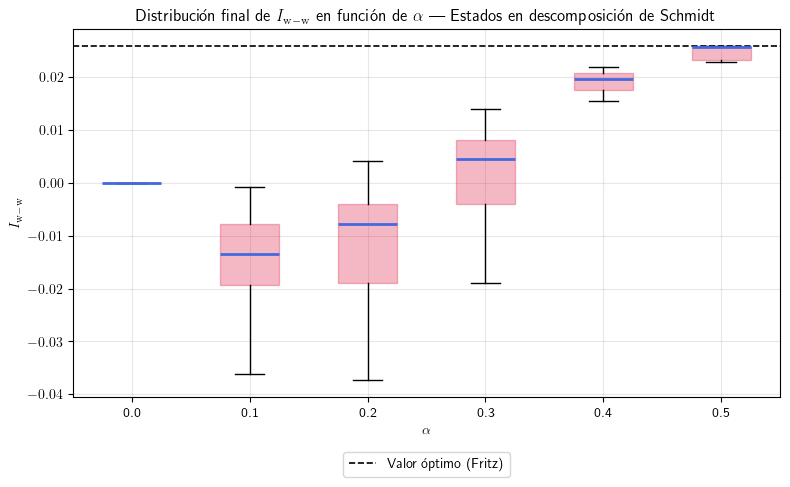

In [81]:
datos_finales = []

for a in alphas_sim01:
    Data = cargar_ultimo_npz(carpeta_sim01, "Sim01", a)
    Out = Data['Out']
    datos_finales.append(Out[:, -1])

plt.figure(figsize=(8,5))
box = plt.boxplot(datos_finales, positions=alphas_sim01, widths=0.05,
                   patch_artist=True, showfliers=False)

for caja in box['boxes']:
    caja.set(facecolor='crimson', alpha=0.3, edgecolor='crimson')
for mediana in box['medians']:
    mediana.set(color='royalblue', linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Distribución final de $I_{\rm w-w}$ en función de $\alpha$ — Estados en descomposición de Schmidt")
plt.xticks(alphas_sim01)
plt.xlim(min(alphas_sim01) - 0.05, max(alphas_sim01) + 0.05)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Simulación 02

**Carpeta de datos:** `Simulacion_02`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| $\alpha$ | $\{0.30,\ 0.35,\ 0.40,\ 0.45,\ 0.50\}$ |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** barrido en $\alpha$ (grado de entrelazamiento) para estados con
descomposición de Schmidt $\sqrt{\alpha}\,|01\rangle+\sqrt{1-\alpha}\,|10\rangle$ aplicados
simétricamente a las tres fuentes de la red triangular. Se guarda, por cada
$\alpha$, el arreglo crudo de las 100 realizaciones junto con promedio,
mediana, Q1 y Q3 por iteración.

**Archivos generados:** `Simulacion_02/Sim02_alpha{valor}_{fecha}.npz`


In [10]:
# ==========================================================
# Simulación 02 — Ejecución
# ==========================================================
alphas_sim02 = [0.30, 0.35, 0.40, 0.45, 0.50]
max_rep_sim02 = 100
max_iter_sim02 = 1000
gains_sim02 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim02 = "Simulacion_02"
fecha_sim02 = datetime.now().strftime("%Y%m%d")

#ejecutar_simulacion(alphas_sim02, max_rep_sim02, max_iter_sim02,
#                     gains_sim02, "Sim02", carpeta_sim02, fecha_sim02)


# Gráficos

Esta sección se ejecuta **después** de correr todas las simulaciones que se
quieran comparar o visualizar. Cada celda siguiente llama a
`graficar_simulacion` indicando el `sim_id` y la `fecha` correspondientes.


In [11]:
import glob

def cargar_ultimo_npz(carpeta, sim_id, alpha):
    patron = os.path.join(carpeta, f"{sim_id}_alpha{alpha:.2f}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para alpha={alpha:.2f} en {carpeta}"
    if len(archivos) > 1:
        print(f"  [aviso] alpha={alpha:.2f} tiene {len(archivos)} archivos, usando el más reciente: {archivos[-1]}")
    return np.load(archivos[-1])

valor_fritz = (np.sqrt(2) - 1) / 16
carpeta_sim02 = "Simulacion_02"
alphas_sim02 = [0.30, 0.35, 0.40, 0.45, 0.50]

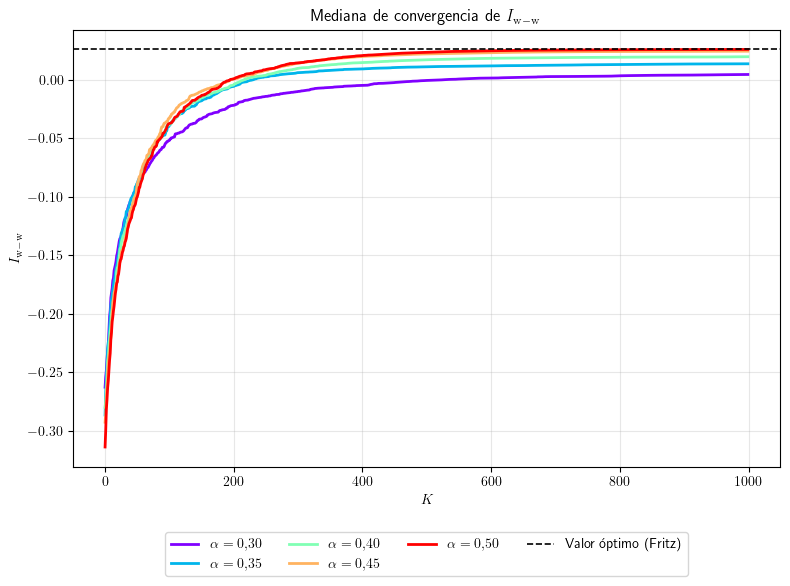

In [13]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(alphas_sim02)))

plt.figure(figsize=(8,6))

for a, color in zip(alphas_sim02, colors):
    Data = cargar_ultimo_npz(carpeta_sim02, "Sim02", a)
    median = Data['median']
    it = np.arange(len(median))

    alpha_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, median, color=color, label=rf"$\alpha = {alpha_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Mediana de convergencia de $I_{\rm w-w}$")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Simulacion_02/Sim02_med.pdf")
plt.savefig("Simulacion_02/Sim02_med.png", dpi=600)
plt.show()

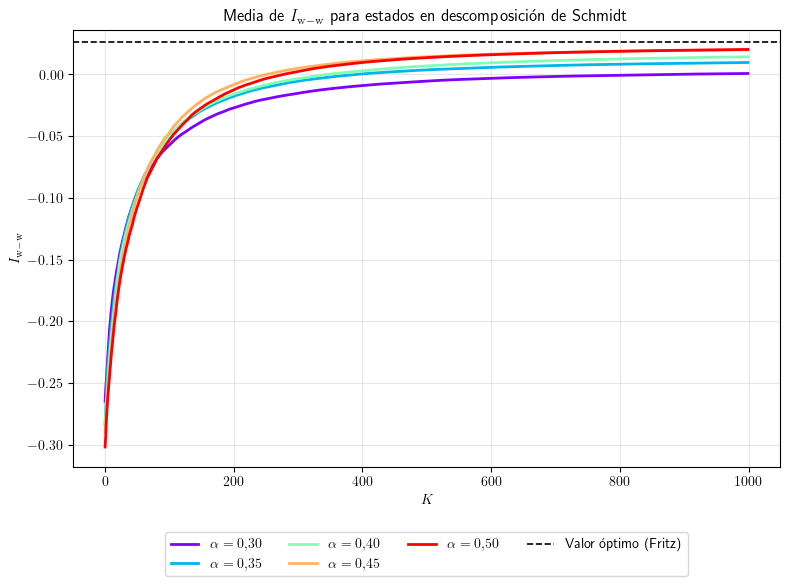

In [86]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(alphas_sim02)))

plt.figure(figsize=(8,6))

for a, color in zip(alphas_sim02, colors):
    Data = cargar_ultimo_npz(carpeta_sim02, "Sim02", a)
    mean = Data['mean']
    it = np.arange(len(mean))

    alpha_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, mean, color=color, label=rf"$\alpha = {alpha_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Media de $I_{\rm w-w}$ para estados en descomposición de Schmidt")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

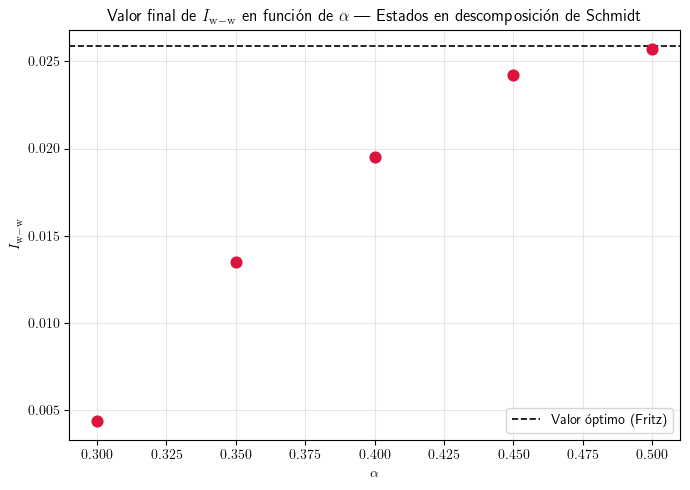

In [87]:
medianas_finales = []

for a in alphas_sim02:
    Data = cargar_ultimo_npz(carpeta_sim02, "Sim02", a)
    medianas_finales.append(Data['median'][-1])

plt.figure(figsize=(7,5))
plt.scatter(alphas_sim02, medianas_finales, color='crimson', s=60, zorder=3)
plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Valor final de $I_{\rm w-w}$ en función de $\alpha$ — Estados en descomposición de Schmidt")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

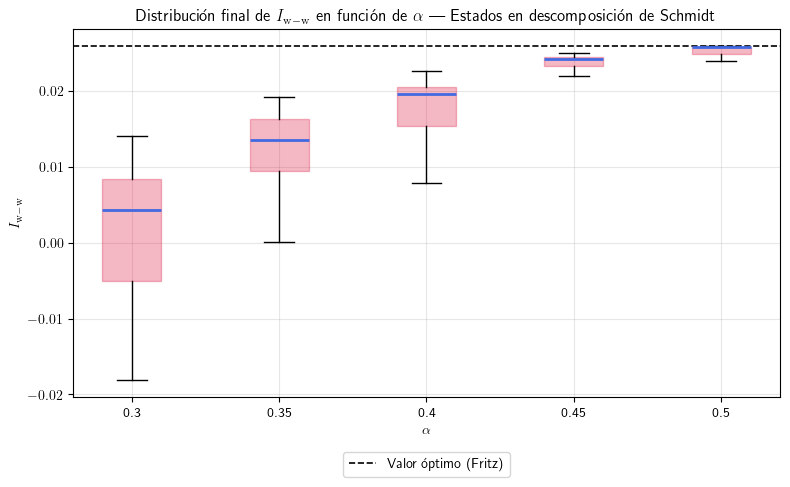

In [88]:
datos_finales = []

for a in alphas_sim02:
    Data = cargar_ultimo_npz(carpeta_sim02, "Sim02", a)
    Out = Data['Out']
    datos_finales.append(Out[:, -1])

plt.figure(figsize=(8,5))
box = plt.boxplot(datos_finales, positions=alphas_sim02, widths=0.02,
                   patch_artist=True, showfliers=False)

for caja in box['boxes']:
    caja.set(facecolor='crimson', alpha=0.3, edgecolor='crimson')
for mediana in box['medians']:
    mediana.set(color='royalblue', linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Distribución final de $I_{\rm w-w}$ en función de $\alpha$ — Estados en descomposición de Schmidt")
plt.xticks(alphas_sim02)
plt.xlim(min(alphas_sim02) - 0.02, max(alphas_sim02) + 0.02)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Simulación 03

**Carpeta de datos:** `Simulacion_03`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| $\alpha$ (fuente variable) | $\{0.0,\ 0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5\}$ |
| $\beta,\ \gamma$ (fuentes fijas) | $0$ (separables) |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** a diferencia de las simulaciones anteriores (mismo $\alpha$
aplicado simétricamente a las tres fuentes), aquí solo la fuente $\alpha$
tiene descomposición de Schmidt variable; las fuentes $\beta$ y $\gamma$
quedan fijas como estados separables ($\alpha=0$). El objetivo es aislar
el efecto de una sola fuente entrelazada sobre $I_{\rm w-w}$.

**Archivos generados:** `Simulacion_03/Sim03_alpha{valor}_{fecha}.npz`

In [89]:
def construir_psi_schmidt(alphas_fuentes):
    """
    Construye el estado Psi de la red triangular donde cada una de las
    tres fuentes (alpha, beta, gamma, en ese orden) tiene su propio
    coeficiente de Schmidt. alphas_fuentes = [a_alpha, a_beta, a_gamma].
    Con a=0 la fuente correspondiente es separable (estado producto).
    """
    kets = []
    for a in alphas_fuentes:
        psi = np.sqrt(a)*np.array([[0, 1, 0, 0]]) + np.sqrt(1-a)*np.array([[0, 0, 1, 0]])
        kets.append(psi)

    Psi = triple_kron(kets[0], kets[1], kets[2])
    Psi = Psi.reshape(6*[2]).transpose([5,0,2,1,4,3]).flatten()
    return Psi


def _una_repeticion_sim03(alpha_variable, gains, max_iter):
    """
    Una repetición de CSPSA para Simulación 03: solo la fuente 'alpha'
    varía; 'beta' y 'gamma' quedan fijas en 0 (separables).
    """
    Psi = construir_psi_schmidt([alpha_variable, 0.0, 0.0])

    Us_in = np.array([ np.kron(random_unitary(2), random_unitary(2)) for _ in range(3) ])
    cspsa = CSPSA(gains=gains, minimize=False)

    results = cspsa.minimize(trineq, Us_in,
                                max_iter,
                                args = (Psi),
                                postprocessing=postprocessing )
    return results.fun


def ejecutar_simulacion_sim03(alphas, max_rep, max_iter, gains, sim_id, carpeta_sim,
                               fecha=None, n_jobs=-1):
    """
    Igual que ejecutar_simulacion, pero para el escenario asimétrico:
    solo una fuente varía en alpha, las otras dos quedan en 0 (separables).
    """
    if fecha is None:
        fecha = datetime.now().strftime("%Y%m%d")

    os.makedirs(carpeta_sim, exist_ok=True)

    for a in alphas:
        print(f"[{sim_id}] alpha = {a:.2f}  (paralelizando {max_rep} repeticiones, n_jobs={n_jobs})")

        resultados = Parallel(n_jobs=n_jobs)(
            delayed(_una_repeticion_sim03)(a, gains, max_iter) for _ in range(max_rep)
        )
        Out = np.array(resultados)

        nombre = f"{sim_id}_alpha{a:.2f}_{fecha}.npz"
        ruta = os.path.join(carpeta_sim, nombre)

        np.savez(ruta,
                 Out=Out,
                 mean=Out.mean(axis=0),
                 median=np.median(Out, axis=0),
                 q1=np.percentile(Out, 25, axis=0),
                 q3=np.percentile(Out, 75, axis=0),
                 alpha=a, gains=gains, max_iter=max_iter,
                 max_rep=max_rep, sim_id=sim_id, fecha=fecha)

        print(f"  Guardado: {ruta}")

In [ ]:
# ==========================================================
# Simulación 03 — Ejecución
# ==========================================================
alphas_sim03 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
max_rep_sim03 = 100
max_iter_sim03 = 1000
gains_sim03 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim03 = "Simulacion_03"
fecha_sim03 = datetime.now().strftime("%Y%m%d")

#ejecutar_simulacion_sim03(alphas_sim03, max_rep_sim03, max_iter_sim03,
#                           gains_sim03, "Sim03", carpeta_sim03, fecha_sim03)

[Sim03] alpha = 0.00  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_alpha0.00_20260804.npz
[Sim03] alpha = 0.10  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_alpha0.10_20260804.npz
[Sim03] alpha = 0.20  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_alpha0.20_20260804.npz
[Sim03] alpha = 0.30  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_alpha0.30_20260804.npz
[Sim03] alpha = 0.40  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_alpha0.40_20260804.npz
[Sim03] alpha = 0.50  (paralelizando 100 repeticiones, n_jobs=-1)
  Guardado: Simulacion_03\Sim03_alpha0.50_20260804.npz


In [91]:
import glob

def cargar_ultimo_npz(carpeta, sim_id, alpha):
    patron = os.path.join(carpeta, f"{sim_id}_alpha{alpha:.2f}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para alpha={alpha:.2f} en {carpeta}"
    if len(archivos) > 1:
        print(f"  [aviso] alpha={alpha:.2f} tiene {len(archivos)} archivos, usando el más reciente: {archivos[-1]}")
    return np.load(archivos[-1])

valor_fritz = (np.sqrt(2) - 1) / 16
carpeta_sim03 = "Simulacion_03"
alphas_sim03 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

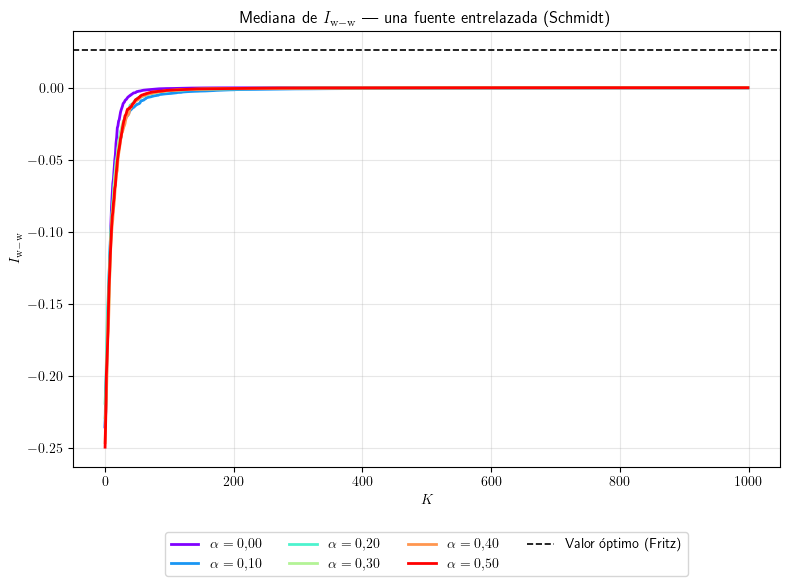

In [92]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(alphas_sim03)))

plt.figure(figsize=(8,6))

for a, color in zip(alphas_sim03, colors):
    Data = cargar_ultimo_npz(carpeta_sim03, "Sim03", a)
    median = Data['median']
    it = np.arange(len(median))

    alpha_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, median, color=color, label=rf"$\alpha = {alpha_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Mediana de $I_{\rm w-w}$ — una fuente entrelazada (Schmidt)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

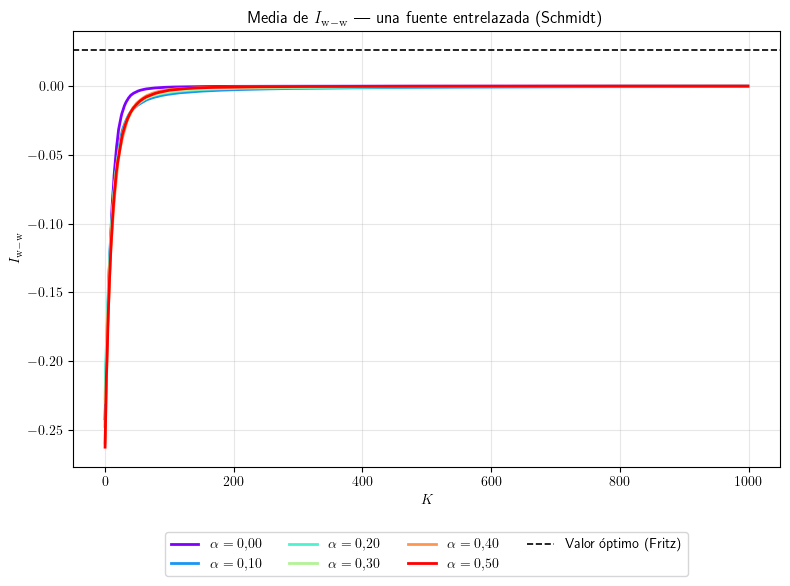

In [93]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(alphas_sim03)))

plt.figure(figsize=(8,6))

for a, color in zip(alphas_sim03, colors):
    Data = cargar_ultimo_npz(carpeta_sim03, "Sim03", a)
    mean = Data['mean']
    it = np.arange(len(mean))

    alpha_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, mean, color=color, label=rf"$\alpha = {alpha_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Media de $I_{\rm w-w}$ — una fuente entrelazada (Schmidt)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

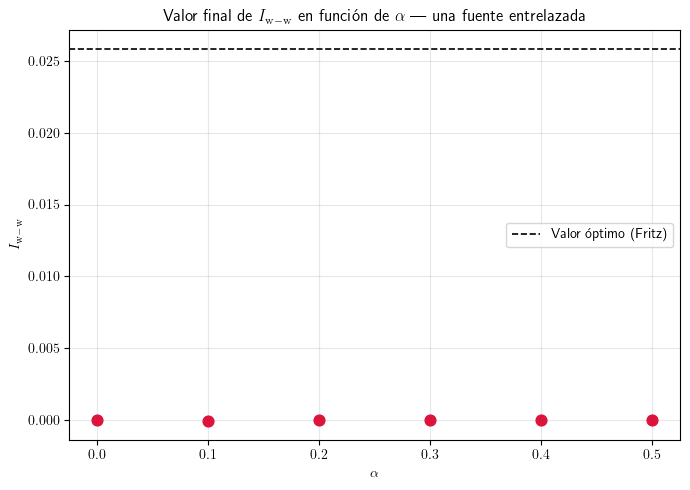

In [94]:
medianas_finales = []

for a in alphas_sim03:
    Data = cargar_ultimo_npz(carpeta_sim03, "Sim03", a)
    medianas_finales.append(Data['median'][-1])

plt.figure(figsize=(7,5))
plt.scatter(alphas_sim03, medianas_finales, color='crimson', s=60, zorder=3)
plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Valor final de $I_{\rm w-w}$ en función de $\alpha$ — una fuente entrelazada")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

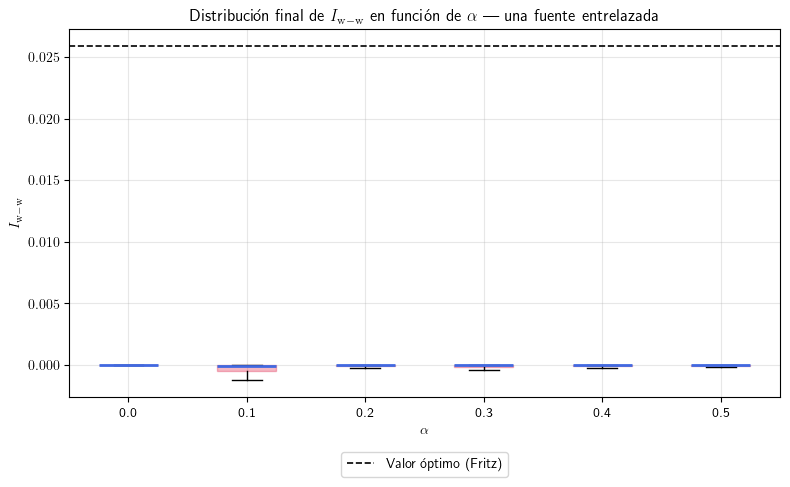

In [95]:
datos_finales = []

for a in alphas_sim03:
    Data = cargar_ultimo_npz(carpeta_sim03, "Sim03", a)
    Out = Data['Out']
    datos_finales.append(Out[:, -1])

plt.figure(figsize=(8,5))
box = plt.boxplot(datos_finales, positions=alphas_sim03, widths=0.05,
                   patch_artist=True, showfliers=False)

for caja in box['boxes']:
    caja.set(facecolor='crimson', alpha=0.3, edgecolor='crimson')
for mediana in box['medians']:
    mediana.set(color='royalblue', linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Distribución final de $I_{\rm w-w}$ en función de $\alpha$ — una fuente entrelazada")
plt.xticks(alphas_sim03)
plt.xlim(min(alphas_sim03) - 0.05, max(alphas_sim03) + 0.05)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Simulación 04

**Carpeta de datos:** `Simulacion_04`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| $\alpha,\ \beta$ (fuentes variables, mismo valor) | $\{0.0,\ 0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5\}$ |
| $\gamma$ (fuente fija) | $0$ (separable) |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** a diferencia de Simulación 03 (una sola fuente entrelazada),
aquí dos fuentes ($\alpha$ y $\beta$) comparten el mismo coeficiente de
Schmidt variable, mientras la tercera ($\gamma$) queda fija como estado
separable ($\gamma=0$). El objetivo es observar el efecto de tener dos
fuentes entrelazadas simultáneamente sobre $I_{\rm w-w}$.

**Archivos generados:** `Simulacion_04/Sim04_alpha{valor}_{fecha}.npz`

In [14]:
def _una_repeticion_sim04(alpha_variable, gains, max_iter):
    """
    Una repetición de CSPSA para Simulación 04: las fuentes 'alpha' y
    'beta' comparten el mismo coeficiente de Schmidt variable; 'gamma'
    queda fija en 0 (separable).
    """
    Psi = construir_psi_schmidt([alpha_variable, alpha_variable, 0.0])

    Us_in = np.array([ np.kron(random_unitary(2), random_unitary(2)) for _ in range(3) ])
    cspsa = CSPSA(gains=gains, minimize=False)

    results = cspsa.minimize(trineq, Us_in,
                                max_iter,
                                args = (Psi),
                                postprocessing=postprocessing )
    return results.fun


def ejecutar_simulacion_sim04(alphas, max_rep, max_iter, gains, sim_id, carpeta_sim,
                               fecha=None, n_jobs=-1):
    """
    Igual que ejecutar_simulacion_sim03, pero para el escenario donde
    dos fuentes (alpha, beta) varían juntas con el mismo valor, y la
    tercera (gamma) queda fija en 0 (separable).
    """
    if fecha is None:
        fecha = datetime.now().strftime("%Y%m%d")

    os.makedirs(carpeta_sim, exist_ok=True)

    for a in alphas:
        print(f"[{sim_id}] alpha = {a:.2f}  (paralelizando {max_rep} repeticiones, n_jobs={n_jobs})")

        resultados = Parallel(n_jobs=n_jobs)(
            delayed(_una_repeticion_sim04)(a, gains, max_iter) for _ in range(max_rep)
        )
        Out = np.array(resultados)

        nombre = f"{sim_id}_alpha{a:.2f}_{fecha}.npz"
        ruta = os.path.join(carpeta_sim, nombre)

        np.savez(ruta,
                 Out=Out,
                 mean=Out.mean(axis=0),
                 median=np.median(Out, axis=0),
                 q1=np.percentile(Out, 25, axis=0),
                 q3=np.percentile(Out, 75, axis=0),
                 alpha=a, gains=gains, max_iter=max_iter,
                 max_rep=max_rep, sim_id=sim_id, fecha=fecha)

        print(f"  Guardado: {ruta}")

In [15]:
# ==========================================================
# Simulación 04 — Ejecución
# ==========================================================
alphas_sim04 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
max_rep_sim04 = 100
max_iter_sim04 = 1000
gains_sim04 = [3, 0, 0.1, 0.602, 0.101]
carpeta_sim04 = "Simulacion_04"
fecha_sim04 = datetime.now().strftime("%Y%m%d")

#ejecutar_simulacion_sim04(alphas_sim04, max_rep_sim04, max_iter_sim04,
#                           gains_sim04, "Sim04", carpeta_sim04, fecha_sim04)

In [16]:
import glob

def cargar_ultimo_npz(carpeta, sim_id, alpha):
    patron = os.path.join(carpeta, f"{sim_id}_alpha{alpha:.2f}_*.npz")
    archivos = sorted(glob.glob(patron))
    assert archivos, f"No se encontró ningún archivo para alpha={alpha:.2f} en {carpeta}"
    if len(archivos) > 1:
        print(f"  [aviso] alpha={alpha:.2f} tiene {len(archivos)} archivos, usando el más reciente: {archivos[-1]}")
    return np.load(archivos[-1])

valor_fritz = (np.sqrt(2) - 1) / 16
carpeta_sim04 = "Simulacion_04"
alphas_sim04 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

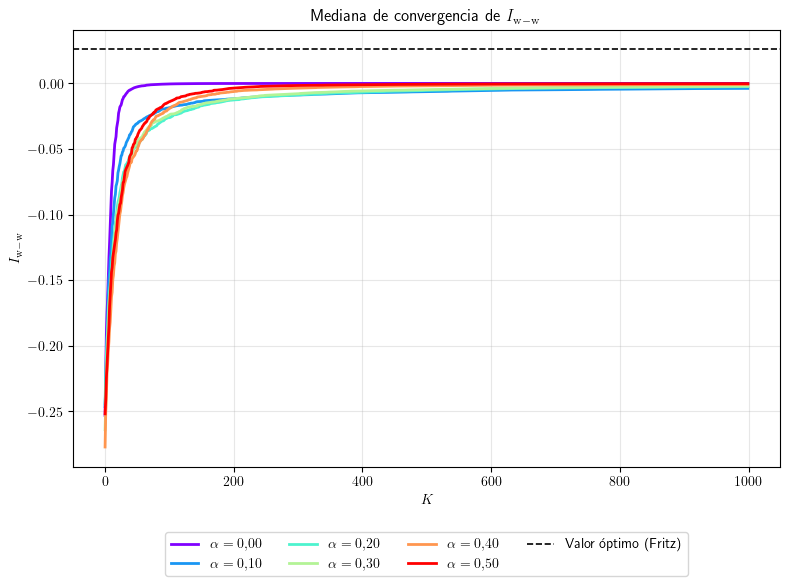

In [17]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(alphas_sim04)))

plt.figure(figsize=(8,6))

for a, color in zip(alphas_sim04, colors):
    Data = cargar_ultimo_npz(carpeta_sim04, "Sim04", a)
    median = Data['median']
    it = np.arange(len(median))

    alpha_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, median, color=color, label=rf"$\alpha = {alpha_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Mediana de convergencia de $I_{\rm w-w}$")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Simulacion_04/Sim04_med.pdf")
plt.savefig("Simulacion_04/Sim04_med.png", dpi=600)
plt.show()

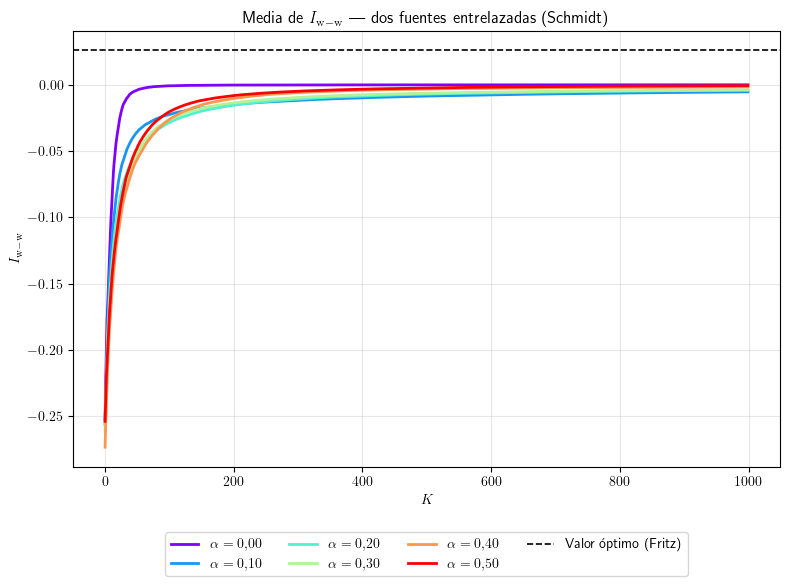

In [100]:
colors = plt.cm.rainbow(np.linspace(0, 1, len(alphas_sim04)))

plt.figure(figsize=(8,6))

for a, color in zip(alphas_sim04, colors):
    Data = cargar_ultimo_npz(carpeta_sim04, "Sim04", a)
    mean = Data['mean']
    it = np.arange(len(mean))

    alpha_str = f"{a:.2f}".replace(".", "{,}")
    plt.plot(it, mean, color=color, label=rf"$\alpha = {alpha_str}$", linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Media de $I_{\rm w-w}$ — dos fuentes entrelazadas (Schmidt)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

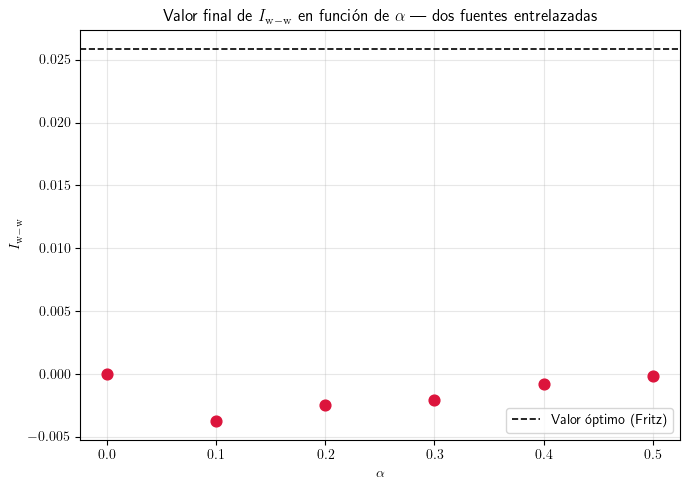

In [101]:
medianas_finales = []

for a in alphas_sim04:
    Data = cargar_ultimo_npz(carpeta_sim04, "Sim04", a)
    medianas_finales.append(Data['median'][-1])

plt.figure(figsize=(7,5))
plt.scatter(alphas_sim04, medianas_finales, color='crimson', s=60, zorder=3)
plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Valor final de $I_{\rm w-w}$ en función de $\alpha$ — dos fuentes entrelazadas")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

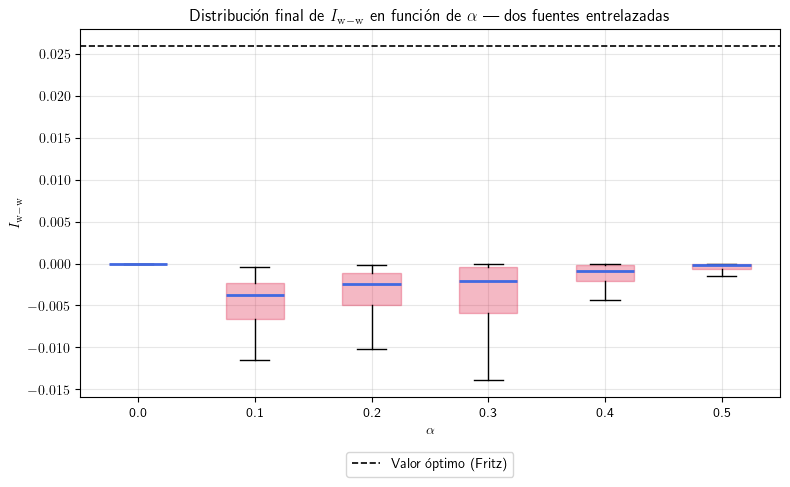

In [103]:
datos_finales = []

for a in alphas_sim04:
    Data = cargar_ultimo_npz(carpeta_sim04, "Sim04", a)
    Out = Data['Out']
    datos_finales.append(Out[:, -1])

plt.figure(figsize=(8,5))
box = plt.boxplot(datos_finales, positions=alphas_sim04, widths=0.05,
                   patch_artist=True, showfliers=False)

for caja in box['boxes']:
    caja.set(facecolor='crimson', alpha=0.3, edgecolor='crimson')
for mediana in box['medians']:
    mediana.set(color='royalblue', linewidth=2)

plt.axhline(valor_fritz, color='black', linestyle='--', linewidth=1.2,
            label=r'Valor óptimo (Fritz)')

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Distribución final de $I_{\rm w-w}$ en función de $\alpha$ — dos fuentes entrelazadas")
plt.xticks(alphas_sim04)
plt.xlim(min(alphas_sim04) - 0.05, max(alphas_sim04) + 0.05)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()